In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import rasterio.warp
import scipy.ndimage
import skimage.measure

In [2]:
FEET_PER_METER = 3.2808398950131

GULLY_SLICE = (slice(7800, 8750), slice(7750, 8500))
ANOTHER_SLICE = (slice(4000, 8000), slice(4000, 8000))

In [3]:
with rasterio.open("../dutch-bill-2022.tif") as file:
    elevation2022 = file.read(1)
    main_transform = file.transform
    main_crs = file.crs
    mask2022 = abs(elevation2022) < 1e30  # True for valid pixels

In [4]:
with rasterio.open("../dutch-bill-2013.tif") as file:
    tmp_original = file.read(1)
    tmp_mask = (tmp_original != file.nodata).astype(np.float32)

    elevation2013 = np.empty(elevation2022.shape, dtype=tmp_original.dtype)
    rasterio.warp.reproject(
        source=tmp_original,
        destination=elevation2013,
        src_transform=file.transform,
        src_crs=file.crs,
        dst_transform=main_transform,
        dst_crs=main_crs,
        resampling=rasterio.warp.Resampling.bilinear,
    )
    elevation2013 /= FEET_PER_METER

    mask = np.empty(elevation2022.shape, dtype=np.float32)
    rasterio.warp.reproject(
        source=tmp_mask,
        destination=mask,
        src_transform=file.transform,
        src_crs=file.crs,
        dst_transform=main_transform,
        dst_crs=main_crs,
        resampling=rasterio.warp.Resampling.bilinear,
    )
    mask = mask > 0.5  # True for valid pixels
    mask &= mask2022

    del tmp_original
    del tmp_mask

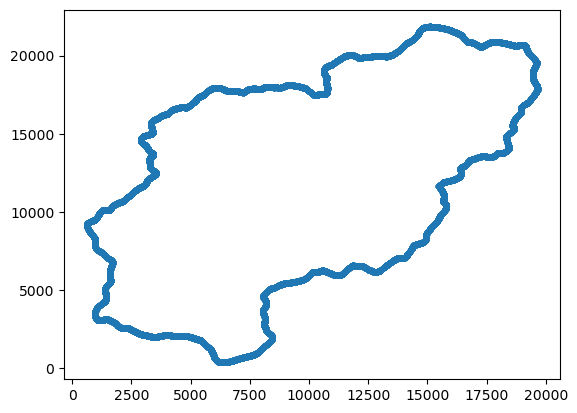

In [5]:
fig, ax = plt.subplots()

tmp2022 = elevation2022.copy()
tmp2013 = elevation2013.copy()
tmp2022[~mask] = np.nan
tmp2013[~mask] = np.nan

ax.scatter(*np.nonzero(tmp2022 - tmp2013 > 100), marker=".")

None

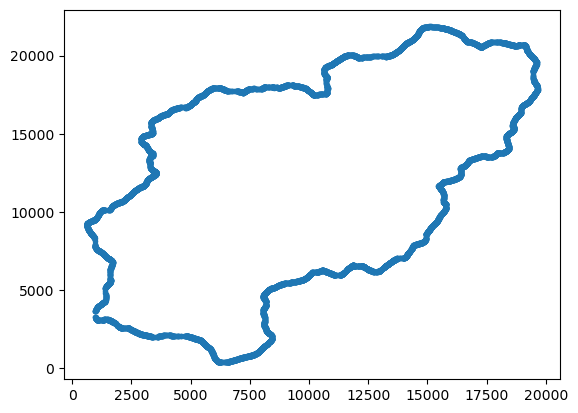

In [6]:
fig, ax = plt.subplots()

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=1)

tmp2022 = elevation2022.copy()
tmp2013 = elevation2013.copy()
tmp2022[~tmp_mask] = np.nan
tmp2013[~tmp_mask] = np.nan

ax.scatter(*np.nonzero(tmp2022 - tmp2013 > 100), marker=".")

None

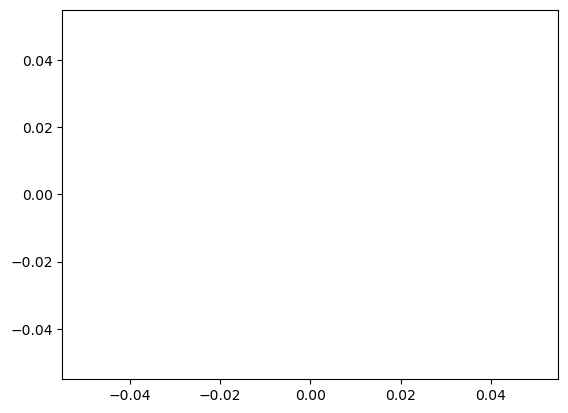

In [7]:
fig, ax = plt.subplots()

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=2)

tmp2022 = elevation2022.copy()
tmp2013 = elevation2013.copy()
tmp2022[~tmp_mask] = np.nan
tmp2013[~tmp_mask] = np.nan

ax.scatter(*np.nonzero(tmp2022 - tmp2013 > 100), marker=".")

None

In [8]:
mask_edges = (
    (np.roll(mask, -1, axis=0) != mask) |
    (np.roll(mask, 1, axis=0) != mask) |
    (np.roll(mask, -1, axis=1) != mask) |
    (np.roll(mask, 1, axis=1) != mask)
)

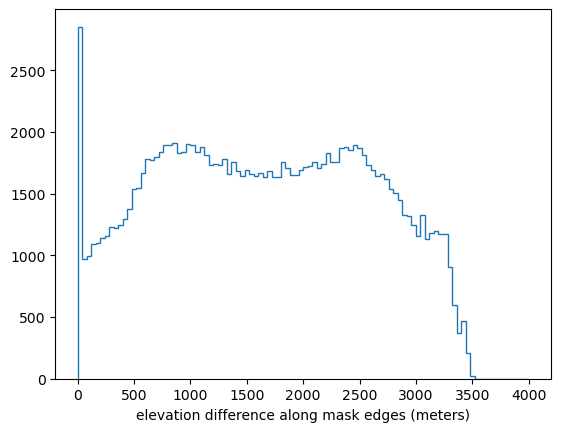

In [9]:
fig, ax = plt.subplots()

ax.hist(elevation2022[mask_edges] - elevation2013[mask_edges], bins=100, range=(0, 4000), histtype="step")

ax.set_xlabel("elevation difference along mask edges (meters)")

None

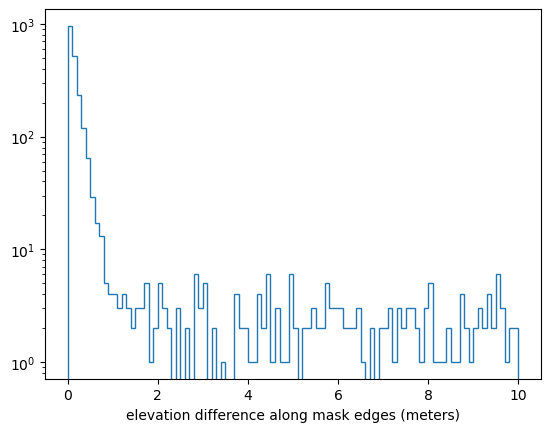

In [10]:
fig, ax = plt.subplots()

ax.hist(elevation2022[mask_edges] - elevation2013[mask_edges], bins=100, range=(0, 10), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("elevation difference along mask edges (meters)")

None

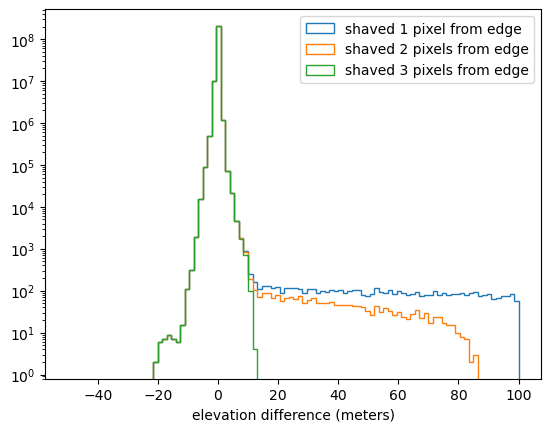

In [11]:
fig, ax = plt.subplots()

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=1)
ax.hist(elevation2022[tmp_mask] - elevation2013[tmp_mask], bins=100, range=(-50, 100), histtype="step", label="shaved 1 pixel from edge")

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=2)
ax.hist(elevation2022[tmp_mask] - elevation2013[tmp_mask], bins=100, range=(-50, 100), histtype="step", label="shaved 2 pixels from edge")

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=3)
ax.hist(elevation2022[tmp_mask] - elevation2013[tmp_mask], bins=100, range=(-50, 100), histtype="step", label="shaved 3 pixels from edge")

ax.legend(loc="upper right")

ax.set_yscale("log")
ax.set_xlabel("elevation difference (meters)")

None

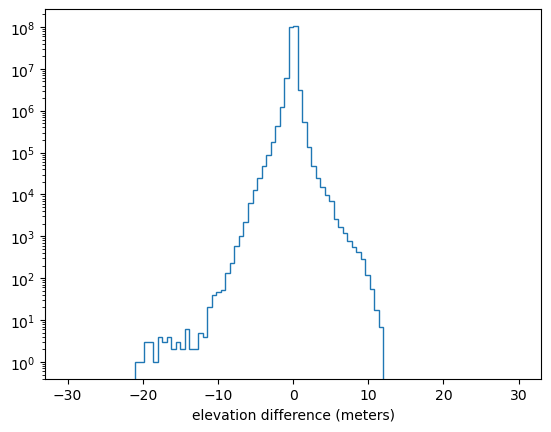

In [12]:
fig, ax = plt.subplots()

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=4)
ax.hist(elevation2022[tmp_mask] - elevation2013[tmp_mask], bins=100, range=(-30, 30), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("elevation difference (meters)")

None

In [38]:
custom_cmap = mpl.colors.LinearSegmentedColormap.from_list('custom_cmap', ['#6f00ff', '#ffffff', '#00a000'], N=256)

In [54]:
levels = [float(x) for x in np.arange(-3, 3 + 1/3 - 1e-5, 1/3) if abs(x) > 1e-5]

In [68]:
difference = elevation2022[ANOTHER_SLICE] - elevation2013[ANOTHER_SLICE]
np.minimum(difference, 6, out=difference)
np.maximum(difference, -6, out=difference)

difference_image = (custom_cmap(difference / 12 + 0.5) * 255).astype(np.uint8)

In [74]:
np.transpose(difference_image, [2, 0, 1]).shape

(4, 4000, 4000)

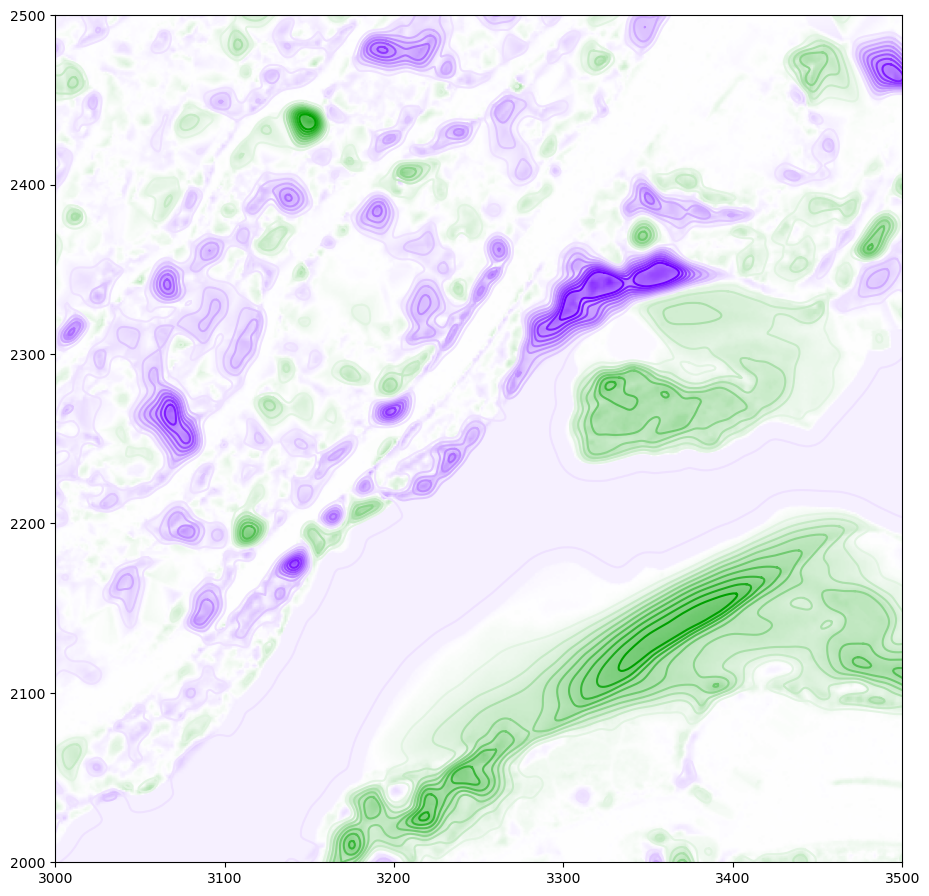

In [71]:
fig, ax = plt.subplots(figsize=(14, 11))

diff = scipy.ndimage.gaussian_filter(elevation2022[ANOTHER_SLICE] - elevation2013[ANOTHER_SLICE], 3)

ax.imshow(difference_image)
# fig.colorbar(p)

for level in levels:
    lines = skimage.measure.find_contours(diff, level)
    for line in lines:
        ax.plot(line[:, 1], line[:, 0], color=custom_cmap(level / 6 + 0.5))

ax.set_xlim(3000, 3500)
ax.set_ylim(2000, 2500)

None